In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [103]:
df = pd.read_csv("..\\output\\wallet_features.csv")

In [104]:
df

,userWallet,n_txns,n_deposits,n_borrows,n_repays,n_redeems,n_liquidations,total_deposited_usd,total_borrowed_usd,unique_assets,active_days,txn_per_day
0,0x00000000001accfa9cef68cf5371a23025b6d4b6,1,1,0,0,0,0,1.987664e+09,0.000000e+00,1,1,1.000000
1,0x000000000051d07a4fb3bd10121a343d85818da6,1,1,0,0,0,0,2.856945e+20,0.000000e+00,1,1,1.000000
2,0x000000000096026fb41fc39f9875d164bd82e2dc,2,2,0,0,0,0,5.152311e+15,0.000000e+00,1,8,0.250000
3,0x0000000000e189dd664b9ab08a33c4839953852c,17,0,0,0,17,0,0.000000e+00,0.000000e+00,4,130,0.130769
4,0x0000000002032370b971dabd36d72f3e5a7bf1ee,399,250,15,4,130,0,2.065773e+23,6.029762e+22,6,133,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3492,0x06185db89f5c8ef5e5a0abc95c5cb69b54c33f30,1,1,0,0,0,0,9.871628e+01,0.000000e+00,1,1,1.000000
3493,0x06189341e523a52ae10c4bd4a7774371fac1b249,7,4,1,0,2,0,1.272592e+19,2.330736e+18,3,1,7.000000
3494,0x0618c450370822c5cb25ec143a3008230d8e2c12,5,1,0,0,4,0,3.530977e+22,0.000000e+00,4,1,5.000000
3495,0x0618e615c8c9b5efc8c8eadc68be7182bdc455e2,22,13,2,2,5,0,6.793268e+21,1.202218e+09,7,32,0.687500


In [105]:
df.columns

Index(['userWallet', 'n_txns', 'n_deposits', 'n_borrows', 'n_repays',
       'n_redeems', 'n_liquidations', 'total_deposited_usd',
       'total_borrowed_usd', 'unique_assets', 'active_days', 'txn_per_day'],
      dtype='object')

In [106]:
df.describe()

,n_txns,n_deposits,n_borrows,n_repays,n_redeems,n_liquidations,total_deposited_usd,total_borrowed_usd,unique_assets,active_days,txn_per_day
count,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3.497000e+03,3.497000e+03,3497.000000,3497.000000,3497.000000
mean,28.595939,10.811553,4.885902,3.589648,9.237918,0.070918,1.205038e+23,7.110951e+22,2.452960,22.593080,1.674585
std,250.732075,29.868997,15.133573,13.374770,242.518307,0.692889,1.706699e+24,1.144582e+24,1.960604,33.174518,4.530480
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.000000,0.020833
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.001414e+09,0.000000e+00,1.000000,1.000000,0.489051
50%,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.964827e+18,0.000000e+00,2.000000,3.000000,1.000000
75%,16.000000,6.000000,3.000000,2.000000,3.000000,0.000000,1.910777e+21,2.503978e+18,3.000000,33.000000,2.000000
max,14265.000000,511.000000,200.000000,291.000000,14265.000000,26.000000,6.056302e+25,3.505958e+25,9.000000,154.000000,216.136364


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3497 entries, 0 to 3496
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   userWallet           3497 non-null   object 
 1   n_txns               3497 non-null   int64  
 2   n_deposits           3497 non-null   int64  
 3   n_borrows            3497 non-null   int64  
 4   n_repays             3497 non-null   int64  
 5   n_redeems            3497 non-null   int64  
 6   n_liquidations       3497 non-null   int64  
 7   total_deposited_usd  3497 non-null   float64
 8   total_borrowed_usd   3497 non-null   float64
 9   unique_assets        3497 non-null   int64  
 10  active_days          3497 non-null   int64  
 11  txn_per_day          3497 non-null   float64
dtypes: float64(3), int64(8), object(1)
memory usage: 328.0+ KB


In [108]:
# Selecting features for clustering
features = [
    'n_txns',
    'n_deposits',
    'n_borrows',
    'n_repays',
    'n_redeems',
    'n_liquidations',
    'total_deposited_usd',
    'total_borrowed_usd',
    'unique_assets',
    'active_days',
    'txn_per_day'
]

In [109]:
X = df[features]

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

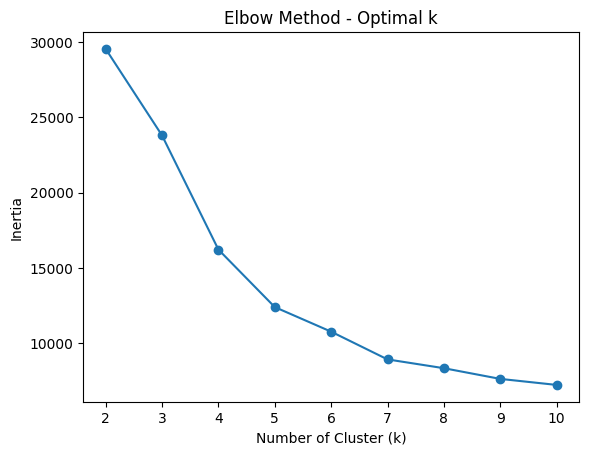

In [110]:
# Elbow Method to choose k
inertia = []
k_range = range(2,11)
for k in k_range :
    model = KMeans(n_clusters= k, random_state = 42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker = 'o' )
plt.title("Elbow Method - Optimal k")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Inertia")
plt.show()



In [111]:
# Optimal K 
optimal_k = 4

In [112]:
kmeans = KMeans(n_clusters= optimal_k, random_state = 42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [113]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

def log_norm(series):
    return normalize(np.log1p(series))

df["proxy_score3"] = (
    + 0.20 * log_norm(df["total_deposited_usd"])         # Deposits reflect credit behavior
    + 0.15 * log_norm(df["total_borrowed_usd"])          # Borrowed implies trust in protocol
    + 0.10 * normalize(df["n_borrows"])                  # Usage of credit
    + 0.10 * normalize(df["n_repays"])                   # Repayments = strong signal
    + 0.10 * normalize(df["unique_assets"])              # Diversification = better user
    + 0.10 * normalize(df["txn_per_day"])                # Consistent use = better
    + 0.10 * log_norm(df["n_deposits"])                  # Deposits = long-term intent
    + 0.05 * log_norm(df["n_txns"])                      # Overall activity
    - 0.05 * normalize(df["n_liquidations"])             # Negative behavior
    - 0.05 * normalize(df["n_redeems"])                  # Slightly negative, usually cashing out
)

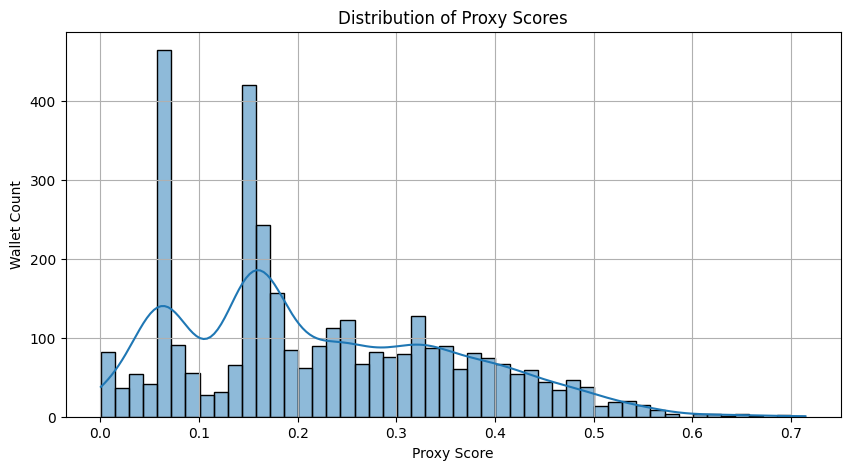

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['proxy_score3'], bins=50, kde=True)
plt.title("Distribution of Proxy Scores")
plt.xlabel("Proxy Score")
plt.ylabel("Wallet Count")
plt.grid(True)
plt.show()

In [115]:
df['proxy_score3'].describe()

count    3497.000000
mean        0.221357
std         0.138153
min         0.000450
25%         0.127896
50%         0.183783
75%         0.324614
max         0.714808
Name: proxy_score3, dtype: float64

In [116]:
# --------- Cluster-Based Risk Scoring ---------
cluster_scores = df.groupby('cluster')['proxy_score3'].mean().sort_values()
cluster_risk_labels = {cluster: idx for idx, cluster in enumerate(cluster_scores.index)}
print(f'Cluster_Scores : \n{cluster_scores}')
print("===============================")
print(f'Cluster_Risk_Labels : \n{cluster_risk_labels}')

Cluster_Scores : 
cluster
1    0.125000
0    0.195228
3    0.479596
2    0.512021
Name: proxy_score3, dtype: float64
Cluster_Risk_Labels : 
{1: 0, 0: 1, 3: 2, 2: 3}


* Cluster 0 has the lowest average proxy_score, so it is likely the riskiest cluster.

* Cluster 1 has the highest average score, so it's the most trustworthy cluster.

* Others fall in between.

Interpretation:

Cluster 0 → Risk level 0 (very high risk)

Cluster 4 → Risk level 1 (high risk)

Cluster 3 → Risk level 2 (moderate)

Cluster 2 → Risk level 3 (low risk)

Cluster 1 → Risk level 4 (very low risk / trustworthy)

In [117]:
# Step 3: Map cluster to score range
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_clusters = np.argsort(cluster_centers)
score_scale = np.linspace(300, 950, optimal_k)

# Corrected mapping using index position
cluster_to_score = {sorted_clusters[i]: int(score_scale[i]) for i in range(optimal_k)}
df["credit_score2"] = df["cluster"].map(cluster_to_score)

In [118]:
df["credit_score"] = 300 + (df["proxy_score3"] / df["proxy_score3"].max()) * (950 - 300)
df["credit_score"] = df["credit_score"].round().astype(int)

In [119]:
df

,userWallet,n_txns,n_deposits,n_borrows,n_repays,n_redeems,n_liquidations,total_deposited_usd,total_borrowed_usd,unique_assets,active_days,txn_per_day,cluster,proxy_score3,credit_score2,credit_score
0,0x00000000001accfa9cef68cf5371a23025b6d4b6,1,1,0,0,0,0,1.987664e+09,0.000000e+00,1,1,1.000000,0,0.083694,NaN,376
1,0x000000000051d07a4fb3bd10121a343d85818da6,1,1,0,0,0,0,2.856945e+20,0.000000e+00,1,1,1.000000,0,0.170247,NaN,455
2,0x000000000096026fb41fc39f9875d164bd82e2dc,2,2,0,0,0,0,5.152311e+15,0.000000e+00,1,8,0.250000,0,0.141884,NaN,429
3,0x0000000000e189dd664b9ab08a33c4839953852c,17,0,0,0,17,0,0.000000e+00,0.000000e+00,4,130,0.130769,0,0.049874,NaN,345
4,0x0000000002032370b971dabd36d72f3e5a7bf1ee,399,250,15,4,130,0,2.065773e+23,6.029762e+22,6,133,3.000000,3,0.505357,NaN,760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3492,0x06185db89f5c8ef5e5a0abc95c5cb69b54c33f30,1,1,0,0,0,0,9.871628e+01,0.000000e+00,1,1,1.000000,0,0.027069,NaN,325
3493,0x06189341e523a52ae10c4bd4a7774371fac1b249,7,4,1,0,2,0,1.272592e+19,2.330736e+18,3,1,7.000000,0,0.318389,NaN,590
3494,0x0618c450370822c5cb25ec143a3008230d8e2c12,5,1,0,0,4,0,3.530977e+22,0.000000e+00,4,1,5.000000,0,0.232003,NaN,511
3495,0x0618e615c8c9b5efc8c8eadc68be7182bdc455e2,22,13,2,2,5,0,6.793268e+21,1.202218e+09,7,32,0.687500,0,0.355721,NaN,623


In [120]:
df.cluster.value_counts()

cluster
0    3175
3     316
2       5
1       1
Name: count, dtype: int64

In [121]:
df['credit_score'].describe()

count    3497.000000
mean      501.290821
std       125.646824
min       300.000000
25%       416.000000
50%       467.000000
75%       595.000000
max       950.000000
Name: credit_score, dtype: float64

In [122]:
df

,userWallet,n_txns,n_deposits,n_borrows,n_repays,n_redeems,n_liquidations,total_deposited_usd,total_borrowed_usd,unique_assets,active_days,txn_per_day,cluster,proxy_score3,credit_score2,credit_score
0,0x00000000001accfa9cef68cf5371a23025b6d4b6,1,1,0,0,0,0,1.987664e+09,0.000000e+00,1,1,1.000000,0,0.083694,NaN,376
1,0x000000000051d07a4fb3bd10121a343d85818da6,1,1,0,0,0,0,2.856945e+20,0.000000e+00,1,1,1.000000,0,0.170247,NaN,455
2,0x000000000096026fb41fc39f9875d164bd82e2dc,2,2,0,0,0,0,5.152311e+15,0.000000e+00,1,8,0.250000,0,0.141884,NaN,429
3,0x0000000000e189dd664b9ab08a33c4839953852c,17,0,0,0,17,0,0.000000e+00,0.000000e+00,4,130,0.130769,0,0.049874,NaN,345
4,0x0000000002032370b971dabd36d72f3e5a7bf1ee,399,250,15,4,130,0,2.065773e+23,6.029762e+22,6,133,3.000000,3,0.505357,NaN,760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3492,0x06185db89f5c8ef5e5a0abc95c5cb69b54c33f30,1,1,0,0,0,0,9.871628e+01,0.000000e+00,1,1,1.000000,0,0.027069,NaN,325
3493,0x06189341e523a52ae10c4bd4a7774371fac1b249,7,4,1,0,2,0,1.272592e+19,2.330736e+18,3,1,7.000000,0,0.318389,NaN,590
3494,0x0618c450370822c5cb25ec143a3008230d8e2c12,5,1,0,0,4,0,3.530977e+22,0.000000e+00,4,1,5.000000,0,0.232003,NaN,511
3495,0x0618e615c8c9b5efc8c8eadc68be7182bdc455e2,22,13,2,2,5,0,6.793268e+21,1.202218e+09,7,32,0.687500,0,0.355721,NaN,623
